# Laboratorio 2 - Deep Learning
## Ejercicio 2 - Similitud de series con catch22

Este notebook es la parte de catch22 del Ejercicio 2: sacamos las 22 características para las 7 series que ya teníamos del Laboratorio 1 (Total, Aérea, Terrestre, Marítima, La Aurora, Valle Nuevo, San Cristóbal). Usamos los mismos `train.csv` y `test.csv` de este repo.

Aquí solo hacemos los incisos 2.1 a 2.4 (qué es catch22, sacar las características, armar la matriz y estandarizarla). El análisis con PCA/clustering/heatmaps (2.5) y las preguntas de interpretación van en `03_catch22_analisis.ipynb`, y el modelo LSTM con catch22 (2.14) va en `04_catch22_lstm.ipynb`.

In [1]:
import os, tempfile
os.environ['NUMBA_CACHE_DIR'] = tempfile.gettempdir()  # evita error de permisos de numba en el Python de Microsoft Store

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.transformations.collection.feature_based import Catch22
from sklearn.preprocessing import StandardScaler

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['figure.figsize'] = (10, 4)

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

## 1. Las 7 series, igual que en el Laboratorio 1

Reconstruimos las mismas series que usamos antes: Total, las 3 vías (Aérea, Terrestre, Marítima) y las 3 fronteras con más movimiento (La Aurora, Valle Nuevo, San Cristóbal).

Para catch22 no hace falta dividir en train/test como con los modelos, porque no estamos prediciendo nada, solo describiendo cómo se comporta cada serie. Por eso usamos el historial completo (train + test juntos).

In [2]:
train = pd.read_csv('train.csv', encoding='utf-8-sig')
test  = pd.read_csv('test.csv',  encoding='utf-8-sig')

for d in (train, test):
    d['fecha'] = pd.to_datetime(d['Año'].astype(str) + '-' + d['Mes cod'].astype(str) + '-01')

def build_total_via(df):
    total = df.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS')
    total.name = 'Total'
    via = df.groupby(['fecha', 'Vía'])['Viajero'].sum().unstack(fill_value=0).sort_index().asfreq('MS')
    return total, via

def build_frontera(df):
    return df.groupby(['fecha', 'Frontera'])['Viajero'].sum().unstack(fill_value=0).sort_index().asfreq('MS')

tot_tr, via_tr = build_total_via(train)
tot_te, via_te = build_total_via(test)
fr_tr, fr_te = build_frontera(train), build_frontera(test)

fronteras_cols = {'01 La Aurora': 'La Aurora', '07 Valle Nuevo': 'Valle Nuevo', '09 San Cristóbal': 'San Cristóbal'}

series = {
    'Total':     pd.concat([tot_tr, tot_te]).sort_index(),
    'Aérea':     pd.concat([via_tr['Aérea'], via_te['Aérea']]).sort_index(),
    'Terrestre': pd.concat([via_tr['Terrestre'], via_te['Terrestre']]).sort_index(),
    'Marítima':  pd.concat([via_tr['Marítima'], via_te['Marítima']]).sort_index(),
}
for col, nombre in fronteras_cols.items():
    series[nombre] = pd.concat([fr_tr[col], fr_te[col]]).sort_index()

print('Series construidas:', list(series.keys()))
print('Rango de fechas:', series['Total'].index.min().date(), '-', series['Total'].index.max().date())
print('Largo de cada serie:', {k: len(v) for k, v in series.items()})

Series construidas: ['Total', 'Aérea', 'Terrestre', 'Marítima', 'La Aurora', 'Valle Nuevo', 'San Cristóbal']
Rango de fechas: 2009-01-01 - 2026-06-01
Largo de cada serie: {'Total': 210, 'Aérea': 210, 'Terrestre': 210, 'Marítima': 210, 'La Aurora': 210, 'Valle Nuevo': 210, 'San Cristóbal': 210}


### Por qué estandarizamos cada serie antes de sacar las características

catch22 espera que la serie ya venga estandarizada (media 0, desviación 1). Si no lo hacíamos, series con escalas muy distintas -- Total tiene cientos de miles de viajeros y San Cristóbal solo miles -- no se podrían comparar bien entre sí.

Ojo: esto es distinto de la estandarización que pide el inciso 2.4. Ahí se estandariza cada característica (columna) de la matriz final, no la serie original.

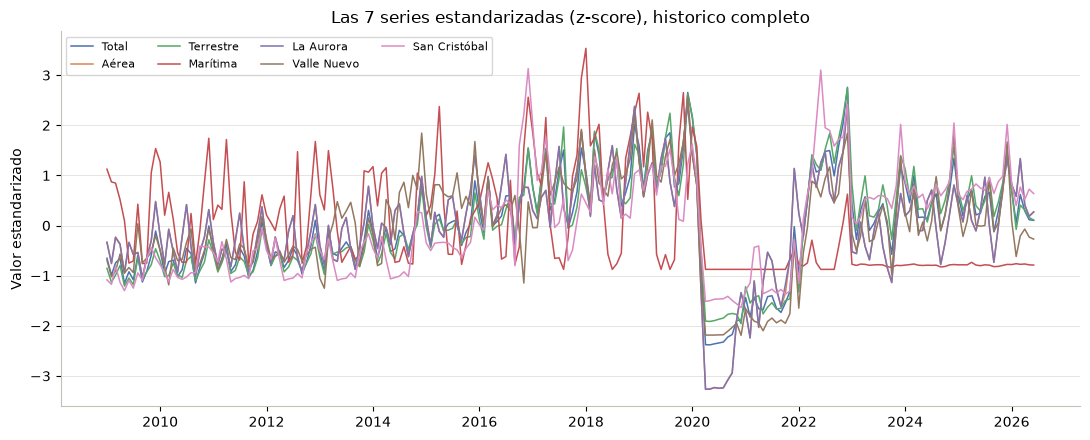

In [3]:
series_z = {nombre: (s.values.astype(float) - s.values.mean()) / s.values.std() for nombre, s in series.items()}

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (nombre, sz) in enumerate(series_z.items()):
    ax.plot(series[nombre].index, sz, color=COLORS[i % len(COLORS)], linewidth=1.1, label=nombre)
ax.set_title('Las 7 series estandarizadas (z-score), historico completo')
ax.set_ylabel('Valor estandarizado')
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()

## 2. Qué es catch22 (2.1)

catch22 es un grupo de 22 características que resumen cómo se comporta una serie de tiempo. Vienen de un trabajo de Fulcher, Little y Jones, que partieron de un set enorme (más de 7000 características, el toolbox hctsa) y se quedaron con las 22 que mejor explican la dinámica de una serie sin repetir información entre ellas.

Cada característica mide algo distinto: autocorrelación, forma de la distribución de los datos, qué tan predecible es, si tiene patrones que se repiten, etc.

Por qué sirve:
- Convierte cualquier serie, sin importar qué tan larga sea, en un vector de 22 números. Así se pueden comparar series de distinto largo sin tener que alinearlas en el tiempo.
- Es rápido de calcular.
- Cada número tiene un significado que se puede explicar, no es una caja negra como un embedding de red neuronal.
- No está pensado para una tarea específica, entonces sirve igual de bien para comparar series muy distintas entre sí, que es justo lo que necesitamos en este ejercicio.

## 3. Sacamos las 22 características (2.2)

Usamos la librería `aeon`, que trae una implementación de catch22 en Python (a diferencia de `pycatch22`, que necesita compilar código en C y no instala fácil en Windows). Le pasamos cada serie ya estandarizada y nos regresa un arreglo de (7 series, 22 características).

In [4]:
feature_names = [
    'DN_HistogramMode_5', 'DN_HistogramMode_10', 'CO_f1ecac', 'CO_FirstMin_ac',
    'CO_HistogramAMI_even_2_5', 'CO_trev_1_num', 'MD_hrv_classic_pnn40',
    'SB_BinaryStats_mean_longstretch1', 'SB_TransitionMatrix_3ac_sumdiagcov',
    'PD_PeriodicityWang_th0_01', 'CO_Embed2_Dist_tau_d_expfit_meandiff',
    'IN_AutoMutualInfoStats_40_gaussian_fmmi', 'FC_LocalSimple_mean1_tauresrat',
    'DN_OutlierInclude_p_001_mdrmd', 'DN_OutlierInclude_n_001_mdrmd',
    'SP_Summaries_welch_rect_area_5_1', 'SB_BinaryStats_diff_longstretch0',
    'SB_MotifThree_quantile_hh', 'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
    'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1', 'SP_Summaries_welch_rect_centroid',
    'FC_LocalSimple_mean3_stderr',
]  # orden canonico de catch22 (Fulcher et al., 2013)

X = [sz.reshape(1, -1) for sz in series_z.values()]
c22 = Catch22(outlier_norm=True, replace_nans=True)
X_c22 = c22.fit_transform(X)

X_c22.shape

(7, 22)

## 4. Matriz serie x característica (2.3)

Cada fila es una serie, cada columna una característica de catch22.

In [5]:
matriz = pd.DataFrame(X_c22, index=series.keys(), columns=feature_names)
matriz.round(3)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.189,-0.582,8.579,10.0,0.454,-0.128,0.914,30.0,0.014,11.0,...,0.056,0.219,0.324,0.833,6.0,1.847,0.762,0.857,0.147,0.629
Aérea,-0.409,-0.123,6.437,10.0,0.207,-0.176,0.962,34.0,0.010,11.0,...,0.071,0.186,0.324,0.760,5.0,1.987,0.857,0.857,0.172,0.745
Terrestre,-0.548,-0.783,8.997,3.0,0.537,-0.088,0.909,30.0,0.006,3.0,...,0.056,0.257,0.310,0.838,6.0,1.768,0.762,0.833,0.123,0.606
Marítima,-0.433,-0.654,2.771,6.0,0.123,-0.083,0.670,9.0,0.008,11.0,...,0.200,0.033,0.424,0.750,5.0,1.843,0.857,0.857,0.515,0.871
La Aurora,-0.412,-0.126,6.450,10.0,0.204,-0.177,0.957,34.0,0.010,11.0,...,0.071,0.190,0.324,0.760,5.0,1.987,0.857,0.857,0.172,0.744
Valle Nuevo,0.200,-0.039,8.791,6.0,0.404,-0.067,0.947,37.0,0.014,7.0,...,0.056,0.171,0.343,0.812,6.0,1.852,0.833,0.833,0.123,0.639
San Cristóbal,0.748,-0.920,8.236,10.0,0.413,-0.017,0.880,52.0,0.040,11.0,...,0.024,0.543,-0.481,0.857,5.0,1.810,0.286,0.810,0.098,0.608


## 5. Estandarizamos las características (2.4)

Ahora sí, estandarizamos cada columna (cada característica) para que ninguna pese más que las otras en el PCA y el clustering solo por tener números más grandes.

In [6]:
matriz_std = pd.DataFrame(
    StandardScaler().fit_transform(matriz),
    index=matriz.index,
    columns=matriz.columns,
)
matriz_std.round(3)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.636,-0.363,0.681,0.811,0.829,-0.413,0.239,-0.194,-0.072,0.588,...,-0.394,-0.066,0.345,0.780,1.155,-0.304,0.089,0.784,-0.340,-0.684
Aérea,-0.702,1.019,-0.362,0.811,-0.886,-1.307,0.746,0.146,-0.404,0.588,...,-0.092,-0.298,0.345,-1.030,-0.866,1.486,0.586,0.784,-0.157,0.580
Terrestre,-1.015,-0.971,0.885,-1.839,1.414,0.304,0.188,-0.194,-0.841,-2.157,...,-0.394,0.199,0.296,0.905,1.155,-1.310,0.089,-0.588,-0.523,-0.934
Marítima,-0.757,-0.581,-2.148,-0.703,-1.474,0.407,-2.346,-1.979,-0.579,0.588,...,2.354,-1.360,0.690,-1.253,-0.866,-0.351,0.586,0.784,2.406,1.958
La Aurora,-0.709,1.009,-0.356,0.811,-0.910,-1.318,0.695,0.146,-0.404,0.588,...,-0.092,-0.265,0.345,-1.014,-0.866,1.486,0.586,0.784,-0.157,0.569
Valle Nuevo,0.660,1.271,0.785,-0.703,0.483,0.704,0.594,0.401,-0.072,-0.784,...,-0.394,-0.398,0.411,0.252,1.155,-0.237,0.461,-0.588,-0.523,-0.572
San Cristóbal,1.887,-1.384,0.515,0.811,0.544,1.622,-0.116,1.675,2.371,0.588,...,-0.987,2.189,-2.431,1.360,-0.866,-0.771,-2.396,-1.961,-0.706,-0.917


## 6. Guardamos los resultados

In [7]:
matriz.to_csv('catch22_features.csv', encoding='utf-8-sig')
matriz_std.to_csv('catch22_features_std.csv', encoding='utf-8-sig')

print('Guardado catch22_features.csv (crudo) y catch22_features_std.csv (estandarizado):', matriz.shape)

Guardado catch22_features.csv (crudo) y catch22_features_std.csv (estandarizado): (7, 22)


## 7. Analisis de la matriz (2.5)

Con `matriz_std` (las caracteristicas ya estandarizadas) hacemos los 5 analisis que pide el inciso 2.5: PCA, clustering, heatmap de caracteristicas, correlacion entre caracteristicas y distancias entre series.

### PCA

Reducimos las 22 caracteristicas a 2 componentes para poder ver las 7 series en un plano y a simple vista notar cuales se parecen entre si.

Varianza explicada acumulada (PC1+PC2): 73.1 %


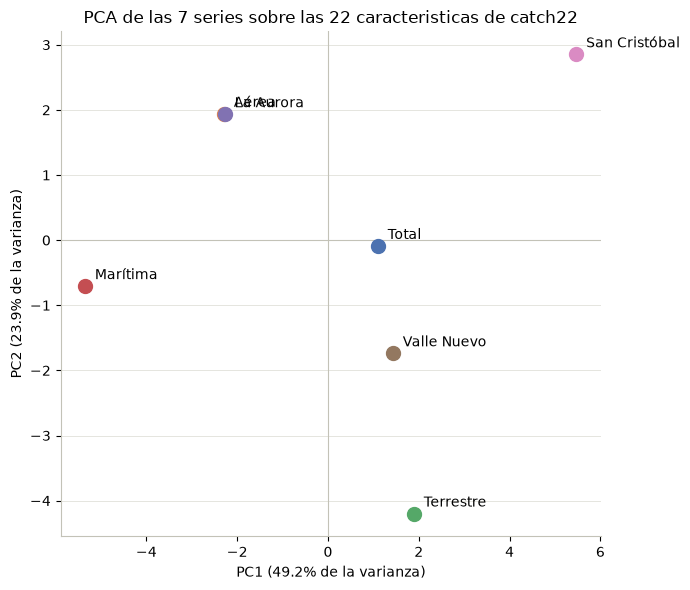

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(matriz_std)

fig, ax = plt.subplots(figsize=(7, 6))
for i, nombre in enumerate(matriz_std.index):
    ax.scatter(coords[i, 0], coords[i, 1], color=COLORS[i % len(COLORS)], s=100, zorder=3)
    ax.annotate(nombre, (coords[i, 0], coords[i, 1]), textcoords='offset points', xytext=(7, 5))
ax.axhline(0, color='#c3c2b7', linewidth=0.8)
ax.axvline(0, color='#c3c2b7', linewidth=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% de la varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% de la varianza)')
ax.set_title('PCA de las 7 series sobre las 22 caracteristicas de catch22')
fig.tight_layout()

print('Varianza explicada acumulada (PC1+PC2):', round(pca.explained_variance_ratio_[:2].sum() * 100, 1), '%')

### Clustering

Clustering jerarquico (metodo ward) sobre las mismas 22 caracteristicas estandarizadas, para ver que series se agrupan primero (las que se agrupan mas abajo en el dendrograma son las mas parecidas).

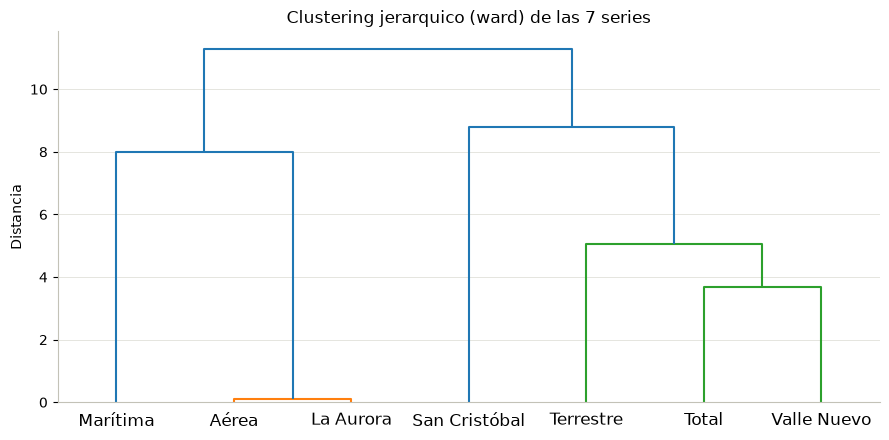

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(matriz_std, method='ward')

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(Z, labels=matriz_std.index.tolist(), color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set_title('Clustering jerarquico (ward) de las 7 series')
ax.set_ylabel('Distancia')
fig.tight_layout()

### Heatmap de caracteristicas

Cada fila es una serie, cada columna una caracteristica de catch22 ya estandarizada (azul = valor bajo, rojo = valor alto respecto a las otras series).

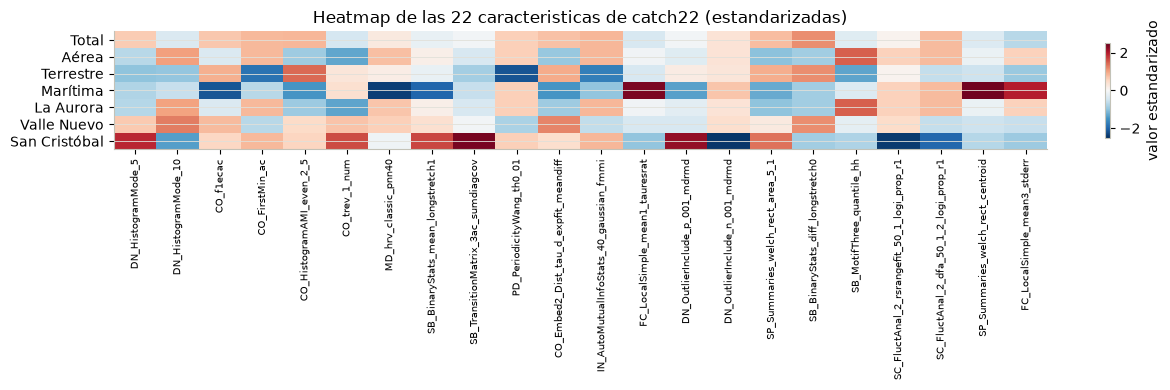

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(matriz_std.values, cmap='RdBu_r', vmin=-2.5, vmax=2.5, aspect='auto')
ax.set_yticks(range(len(matriz_std.index)))
ax.set_yticklabels(matriz_std.index)
ax.set_xticks(range(len(matriz_std.columns)))
ax.set_xticklabels(matriz_std.columns, rotation=90, fontsize=7)
ax.set_title('Heatmap de las 22 caracteristicas de catch22 (estandarizadas)')
fig.colorbar(im, ax=ax, shrink=0.8, label='valor estandarizado')
fig.tight_layout()

### Correlacion entre caracteristicas

Aqui no comparamos series, comparamos las 22 caracteristicas entre si (sobre las 7 series). Sirve para ver cuales caracteristicas dan mas o menos la misma informacion.

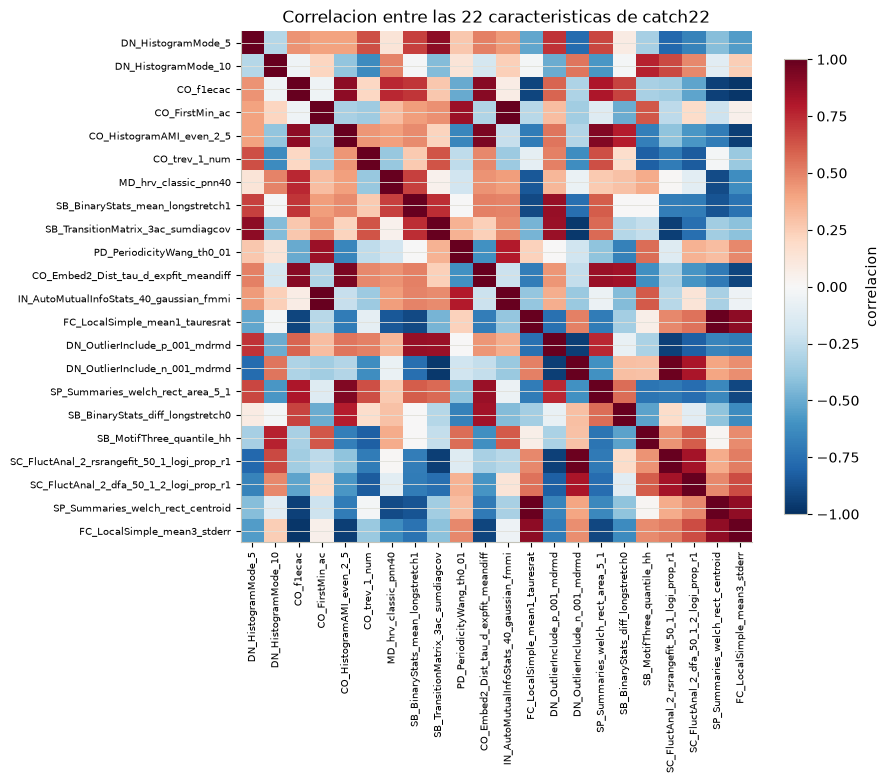

In [11]:
corr = matriz_std.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title('Correlacion entre las 22 caracteristicas de catch22')
fig.colorbar(im, ax=ax, shrink=0.8, label='correlacion')
fig.tight_layout()

### Mapa de distancias entre series

Distancia euclidiana entre cada par de series, calculada sobre las 22 caracteristicas estandarizadas. Entre mas oscuro, mas parecidas son dos series.

,Total,Aérea,Terrestre,Marítima,La Aurora,Valle Nuevo,San Cristóbal
Total,0.00,4.95,5.36,8.30,4.92,3.68,6.94
Aérea,4.95,0.00,7.70,6.93,0.09,5.70,9.00
Terrestre,5.36,7.70,0.00,9.03,7.68,4.08,8.41
Marítima,8.30,6.93,9.03,0.00,6.93,8.58,11.46
La Aurora,4.92,0.09,7.68,6.93,0.00,5.69,8.98
Valle Nuevo,3.68,5.70,4.08,8.58,5.69,0.00,7.44
San Cristóbal,6.94,9.00,8.41,11.46,8.98,7.44,0.00


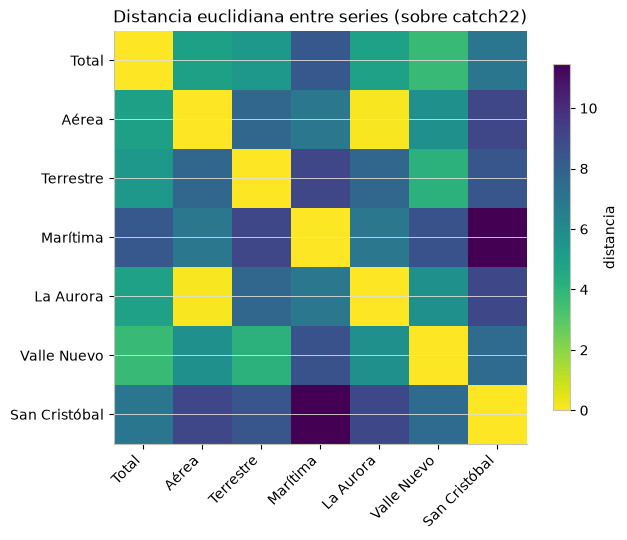

In [12]:
from scipy.spatial.distance import pdist, squareform

dist = squareform(pdist(matriz_std, metric='euclidean'))
dist_df = pd.DataFrame(dist, index=matriz_std.index, columns=matriz_std.index)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(dist_df.values, cmap='viridis_r')
ax.set_xticks(range(len(dist_df.columns)))
ax.set_xticklabels(dist_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(dist_df.index)))
ax.set_yticklabels(dist_df.index)
ax.set_title('Distancia euclidiana entre series (sobre catch22)')
fig.colorbar(im, ax=ax, shrink=0.8, label='distancia')
fig.tight_layout()

dist_df.round(2)